## Topic: Grading System __ without LLM integrate

In [ ]:
""" 

Example 1: Multi-Way Routing (Grading System)
──────────────────────────────────────────────
Flow:
  START → evaluate ──┬──→ excellent  (score ≥ 90) → END
                     ├──→ good       (score ≥ 70) → END
                     └──→ needs_work (score < 70) → END

Demonstrates:
  - Three-way branching
  - Based on the student name and score we give me the student a grade and a feedback.


State:
  - Student name -> str
  - score -> float
  - grade -> str
  - feedback -> str

  
- Graph:
=============
              ┌───────┐
              │ START │
              └───┬───┘
                  │
                  ▼
             ┌──────────┐
             │ evaluate │  
             └────┬─────┘
                  │
          route_by_score()
        ┌─────────┼─────────┐
        │         │         │
     ≥ 90      ≥ 70       < 70
        │         │         │
        ▼         ▼         ▼
   ┌─────────┐ ┌──────┐ ┌──────────┐
   │excellent│ │ good │ │needs_work│
   └────┬────┘ └──┬───┘ └────┬─────┘
        │         │          │
        ▼         ▼          ▼
       END       END        END  



"""

In [1]:
# Import necessary Libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

c:\Users\kz\anaconda3\envs\GenAI\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


### 1. Define state

In [2]:
class GradeState(TypedDict):
    student: str
    score: int
    grade: str
    feedback: str 

In [3]:
# 1. evaluate node
def evaluate(state: GradeState)-> dict:
    """Evaluate the student's score."""
    print(f"  [evaluate] {state['student']}: {state['score']}%")
    return {}

In [ ]:
# 3. excellent
def excellent_node(state: GradeState) -> dict:
    """Handle excellent performance."""
    print(" [excellent] Outstanding!")
    return {
        "grade": "A+",
        "feedback": f"Exceptional work, {state['student']}! Keep it up!"
    }

# good_node
def good_node(state: GradeState) -> dict:
    """Handle good performance."""
    print(" [good] Solid performance")
    return {
        "grade": "B+",
        "feedback": f"Good job, {state['student']}. A few areas to improve."
    }

# needs_work node
def needs_work(state: GradeState) -> dict:
    """Handle underperformance."""
    print("  [needs_work] Requires improvement")
    return{
        "grade": "C",
        "feedback": f"{state['student']}, please review the material and try again."
    }

In [8]:
# 2. route_by_score
def route_by_score(state: GradeState) -> Literal["excellent_node", "good_node", "needs_work"]:
    """Route to the appropriate feedback node."""
    
    if (state['score'] >= 90):
        return "excellent_node"
    
    elif (state['score'] >=70):
        return "good_node"

    else:
        return "needs_work"


### 2. Create Graph

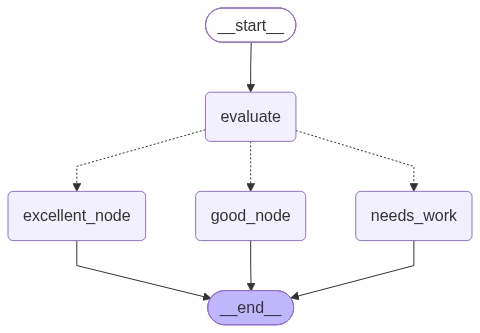

In [10]:
graph = StateGraph(GradeState)

# add nodes
graph.add_node("evaluate", evaluate)
graph.add_node("excellent_node", excellent_node)
graph.add_node("good_node", good_node)
graph.add_node("needs_work", needs_work)


# add edges
graph.add_edge(START, "evaluate")

# conditional edges
graph.add_conditional_edges("evaluate", route_by_score)

graph.add_edge("excellent_node", END)
graph.add_edge("good_node", END)
graph.add_edge("needs_work", END)

# compile 
graph.compile()

In [13]:
print("Running Multi-Way Grading System\n")

workflow = graph.compile()

students = [
    {"student": "Kz", "score": 95},
    {"student": "Bob", "score": 78 },
    {"student": "Charlie", "score": 55},
]

for s in students:
    result = workflow.invoke(s)
    print(f"  {result['student']}: Grade {result['grade']} — {result['feedback']}\n")

Running Multi-Way Grading System

  [evaluate] Kz: 95%
  [excellent] Outstanding!
  Kz: Grade A+ — Exceptional work, Kz! Keep it up!

  [evaluate] Bob: 78%
  [good] Solid performance
  Bob: Grade B — Good job, Bob. A few areas to improve.

  [evaluate] Charlie: 55%
  [needs_work] Requires improvement
  Charlie: Grade C — Charlie, please review the material and try again.



In [7]:
"""
Example 2: Multi-Way Routing (Grading System)
──────────────────────────────────────────────
Flow:
  START → evaluate ──┬──→ excellent  (score ≥ 90) → END
                     ├──→ good       (score ≥ 70) → END
                     └──→ needs_work (score < 70) → END

Demonstrates:
  ✅ Three-way branching
  ✅ Router with multiple conditions
  ✅ Different processing per branch
"""

from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# 1. STATE
class GradeState(TypedDict):
    student: str
    score: int
    grade: str
    feedback: str


# 2. NODES
def evaluate_node(state: GradeState) -> dict:
    """Evaluate the student's score."""
    print(f"  [evaluate] {state['student']}: {state['score']}%")
    return {}


def excellent_node(state: GradeState) -> dict:
    """Handle excellent performance."""
    print("  [excellent] Outstanding!")
    return {
        "grade": "A+",
        "feedback": f"Exceptional work, {state['student']}! Keep it up!"
    }


def good_node(state: GradeState) -> dict:
    """Handle good performance."""
    print("  [good] Solid performance")
    return {
        "grade": "B",
        "feedback": f"Good job, {state['student']}. A few areas to improve."
    }


def needs_work_node(state: GradeState) -> dict:
    """Handle underperformance."""
    print("  [needs_work] Requires improvement")
    return {
        "grade": "C",
        "feedback": f"{state['student']}, please review the material and try again."
    }


# 3. ROUTER FUNCTION (three-way!)
def route_by_score(state: GradeState) -> str:
    """Route to the appropriate feedback node."""
    if state["score"] >= 90:
        return "excellent"
    elif state["score"] >= 70:
        return "good"
    else:
        return "needs_work"


# 4. BUILD GRAPH
graph = StateGraph(GradeState)

graph.add_node("evaluate", evaluate_node)
graph.add_node("excellent", excellent_node)
graph.add_node("good", good_node)
graph.add_node("needs_work", needs_work_node)

graph.add_edge(START, "evaluate")

# THREE-WAY CONDITIONAL EDGE
graph.add_conditional_edges(
    "evaluate",
    route_by_score,
    {
        "excellent": "excellent",
        "good": "good",
        "needs_work": "needs_work"
    }
)

graph.add_edge("excellent", END)
graph.add_edge("good", END)
graph.add_edge("needs_work", END)

# 5. COMPILE & RUN
app = graph.compile()

print("🚀 Running Multi-Way Grading System\n")

students = [
    {"student": "Alice", "score": 95, "grade": "", "feedback": ""},
    {"student": "Bob", "score": 78, "grade": "", "feedback": ""},
    {"student": "Charlie", "score": 55, "grade": "", "feedback": ""},
]

for s in students:
    result = app.invoke(s)
    print(f"  ✅ {result['student']}: Grade {result['grade']} — {result['feedback']}\n")

🚀 Running Multi-Way Grading System

  [evaluate] Alice: 95%
  [excellent] Outstanding!
  ✅ Alice: Grade A+ — Exceptional work, Alice! Keep it up!

  [evaluate] Bob: 78%
  [good] Solid performance
  ✅ Bob: Grade B — Good job, Bob. A few areas to improve.

  [evaluate] Charlie: 55%
  [needs_work] Requires improvement
  ✅ Charlie: Grade C — Charlie, please review the material and try again.

